### imports

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

### datasets

In [2]:
df = pd.read_csv("../data/india_job_market_2024_2026.csv")

### analysis

In [10]:
df.shape

df.dtypes

Job_ID                    str
Job_Title                 str
Company                   str
Company_Type              str
Industry                  str
City                      str
Location_Tier             str
Experience_Level          str
Job_Type                  str
Work_Mode                 str
Salary_LPA            float64
Skills_Required           str
Education_Required        str
Openings                int64
Applicants              int64
Company_Rating        float64
Date_Posted               str
Experience_Numeric      int64
education_numeric       int64
dtype: object

### feature engineering


In [4]:
exp_mapping = {
    'Fresher (0-1 yr)': 1,
    'Junior (1-3 yrs)': 2,
    'Mid (3-6 yrs)': 3,
    'Senior (6-10 yrs)': 4,
    'Lead (10+ yrs)': 5
}

df['Experience_Numeric'] = df['Experience_Level'].map(exp_mapping)


In [5]:
education_map = {
    'B.Com + Certification': 0,
    'B.Sc (CS/IT)': 1,
    'BCA': 2,
    'B.Tech/B.E.': 3,
    'MBA': 4,
    'MCA': 5,
    'M.Tech/M.E.': 6,
    'PhD': 7
}

df['education_numeric'] = df['Education_Required'].map(education_map)

df.dtypes

numeric_cols = df.select_dtypes(include=['number']).columns.drop('Salary_LPA')
X = df[numeric_cols]
y = df.Salary_LPA

X

,Openings,Applicants,Company_Rating,Experience_Numeric,education_numeric
0,3,276,4.0,4,6
1,3,325,4.0,4,3
2,5,559,3.6,4,5
3,3,184,3.5,3,2
4,1,64,3.9,2,5
...,...,...,...,...,...
4995,2,72,4.2,1,3
4996,1,76,4.0,1,3
4997,2,72,3.1,3,3
4998,3,187,3.9,3,2


### modeling


In [6]:
job_model = DecisionTreeRegressor(random_state=1)

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

job_model.fit(train_X,train_y)

predictions = job_model.predict(val_X)

mean_absolute_error(val_y, predictions)

9.4062

In [7]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=1)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print(f"Max leaf nodes: {max_leaf_nodes}  \t\t Mean Absolute Error: {my_mae}")

Max leaf nodes: 5  		 Mean Absolute Error: 6.108022322054811
Max leaf nodes: 50  		 Mean Absolute Error: 6.790479325564543
Max leaf nodes: 500  		 Mean Absolute Error: 7.969417201554938
Max leaf nodes: 5000  		 Mean Absolute Error: 9.245719999999999


NameError: name 'dataset' is not defined

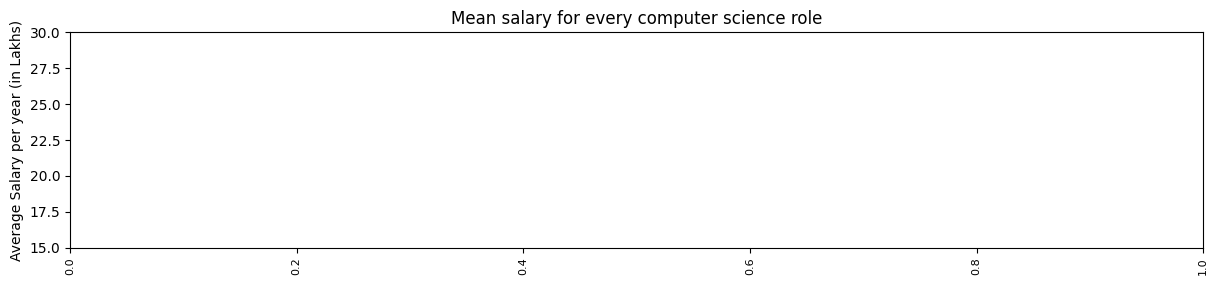

In [8]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Mean salary for every computer science role")
plt.ylim(15, 30)
plt.ylabel("Average Salary per year (in Lakhs)")
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset)

In [ ]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Number of fresher jobs per CS role")
#plt.ylim(15, 30)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset2)

In [ ]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Percent of fresher jobs per CS role")
plt.ylim(10, 30)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = result)

In [ ]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Number of applicants per role")
plt.ylim(220, 360)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset4)
plt.show()